# 03 Acquisition, retention and product mix

Three questions here. Which channels bring users who are actually worth having, whether those users come back, and which products carry the revenue.

Channels are attributed on first touch from `dim_users`, so a channel is judged on the users it introduced rather than on the session that happened to close the sale.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ga4_growth import metrics, viz
from ga4_growth.warehouse import query

viz.setup()
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)

## Channel volume against channel quality

In [2]:
acq = metrics.acquisition_quality("source_medium")
acq[["segment", "acquired_users", "user_share", "sessions_per_user", "view_to_cart_rate",
     "user_conversion_rate", "revenue_per_user", "revenue_share", "returning_user_rate",
     "repeat_customer_rate"]].round(4)

,segment,acquired_users,user_share,sessions_per_user,view_to_cart_rate,user_conversion_rate,revenue_per_user,revenue_share,returning_user_rate,repeat_customer_rate
0,google / organic,39111,0.2607,1.52,0.1398,0.0250,1.9458,0.2435,0.3299,0.0727
1,(direct) / (none),32892,0.2193,1.59,0.1642,0.0369,2.7191,0.2862,0.3552,0.0815
2,google / cpc,29917,0.1994,1.58,0.1619,0.0349,2.6138,0.2502,0.3508,0.0910
3,facebook / paid_social,24108,0.1607,1.35,0.0618,0.0071,0.5149,0.0397,0.2506,0.0176
4,youtube.com / referral,12000,0.0800,1.41,0.0834,0.0117,0.9161,0.0352,0.2795,0.0286
5,newsletter / email,7494,0.0500,1.69,0.2219,0.0607,4.8154,0.1155,0.3866,0.1143
6,partners / affiliate,4478,0.0299,1.61,0.1851,0.0259,2.0659,0.0296,0.3600,0.0862


'reports\\figures\\03_channel_quadrant.png'

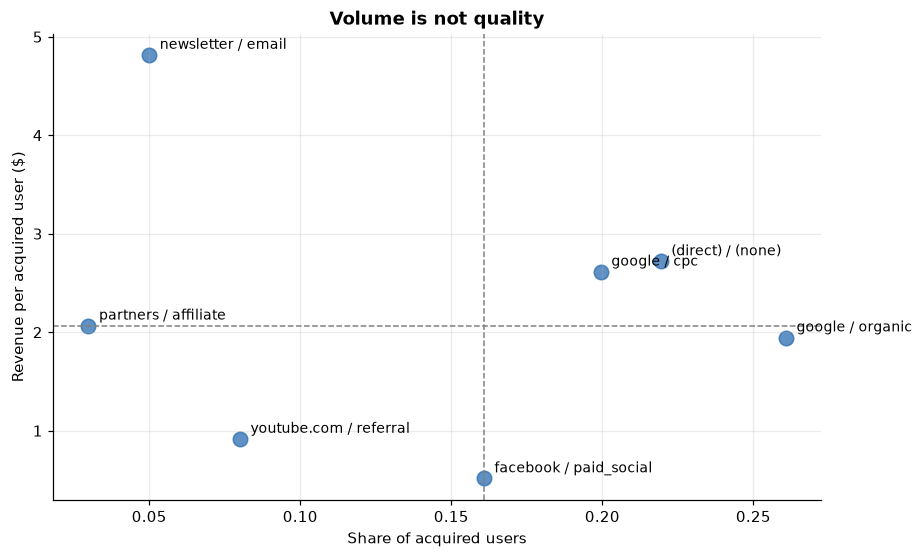

In [3]:
# Share of users against revenue per user. Anything far below the median line on
# the right hand side is buying traffic that does not pay for itself.
fig = viz.scatter_quadrant(
    acq, x="user_share", y="revenue_per_user", label="segment",
    title="Volume is not quality",
    xlabel="Share of acquired users", ylabel="Revenue per acquired user ($)",
)
viz.save(fig, "03_channel_quadrant")

,segment,user_share,revenue_share,share_gap
3,facebook / paid_social,0.1607,0.0397,-0.1210
4,youtube.com / referral,0.0800,0.0352,-0.0448
0,google / organic,0.2607,0.2435,-0.0172
6,partners / affiliate,0.0299,0.0296,-0.0002
2,google / cpc,0.1994,0.2502,0.0508
5,newsletter / email,0.0500,0.1155,0.0655
1,(direct) / (none),0.2193,0.2862,0.0669


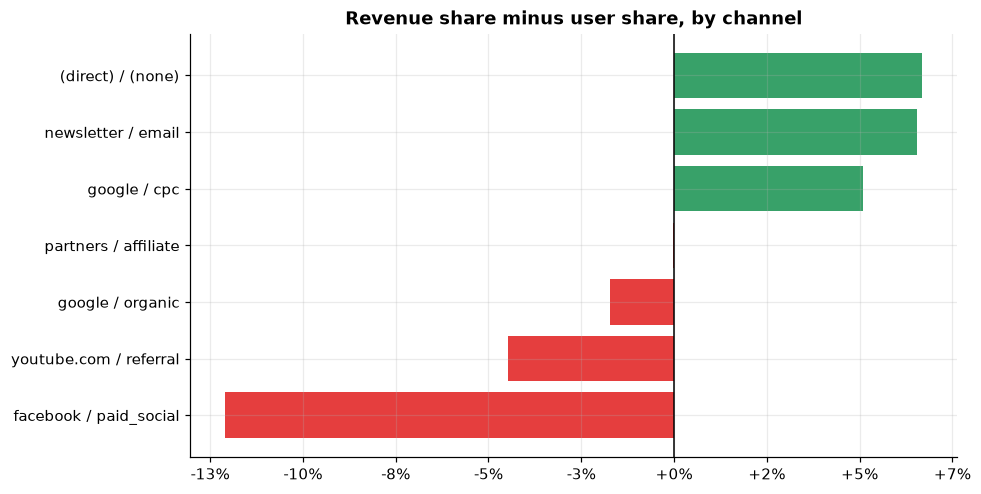

In [4]:
# The same table read as a gap between how much traffic a channel sends and how
# much revenue comes back out of it.
gap = acq[["segment", "user_share", "revenue_share"]].copy()
gap["share_gap"] = gap["revenue_share"] - gap["user_share"]
gap = gap.sort_values("share_gap")

fig, ax = plt.subplots(figsize=(9, 5))
colors = [viz.PALETTE[4] if v < 0 else viz.PALETTE[2] for v in gap["share_gap"]]
ax.barh(gap["segment"], gap["share_gap"], color=colors)
ax.axvline(0, color="black", lw=1)
ax.xaxis.set_major_formatter(lambda v, _: f"{v:+.0%}")
ax.set_title("Revenue share minus user share, by channel")
viz.save(fig, "03_channel_share_gap")
gap.round(4)

In [5]:
# Campaign level, because "paid social is bad" is not an action. Knowing which
# campaign inside it is bad is.
query("""
SELECT acquisition_source || ' / ' || acquisition_medium AS source_medium,
       acquisition_campaign,
       count(*)                                          AS users,
       round(avg(total_sessions), 2)                      AS sessions_per_user,
       round(count(*) FILTER (WHERE is_customer) / count(*), 4) AS user_conversion_rate,
       round(sum(total_revenue) / count(*), 2)            AS revenue_per_user
FROM dim_users
GROUP BY 1, 2
HAVING count(*) > 500
ORDER BY users DESC
""")

,source_medium,acquisition_campaign,users,sessions_per_user,user_conversion_rate,revenue_per_user
0,google / organic,(organic),39111,1.52,0.0250,1.95
1,(direct) / (none),(direct),32892,1.59,0.0369,2.72
2,facebook / paid_social,prospecting_broad,24108,1.35,0.0071,0.51
3,google / cpc,shopping_feed,16424,1.55,0.0308,2.33
4,google / cpc,brand_search,13493,1.60,0.0399,2.96
5,youtube.com / referral,(referral),12000,1.41,0.0117,0.92
6,newsletter / email,weekly_drop,7494,1.69,0.0607,4.82
7,partners / affiliate,coupon_partners,4478,1.61,0.0259,2.07


## Do users come back

Weekly acquisition cohorts. Week 0 is the week the user first appeared, so it is 100% by construction and the interesting part starts at week 1.

The last few cohorts have barely any history, so anything past `weeks_observed` is missing rather than zero.

week_index,0,1,2,3,4,5,6,7,8
acquisition_week,,,,,,,,,
2024-08-26,1.0,0.289,0.133,0.058,0.032,0.018,0.014,0.012,0.012
2024-09-02,1.0,0.212,0.095,0.046,0.025,0.013,0.008,0.004,0.003
2024-09-09,1.0,0.218,0.096,0.049,0.026,0.013,0.007,0.005,0.004
2024-09-16,1.0,0.210,0.089,0.041,0.025,0.014,0.006,0.004,0.003
2024-09-23,1.0,0.210,0.093,0.044,0.024,0.013,0.009,0.005,0.003
2024-09-30,1.0,0.213,0.089,0.046,0.026,0.014,0.009,0.005,0.003
2024-10-07,1.0,0.221,0.095,0.045,0.024,0.014,0.009,0.005,NaN
2024-10-14,1.0,0.220,0.096,0.049,0.025,0.017,0.009,NaN,NaN
2024-10-21,1.0,0.217,0.093,0.047,0.029,0.016,NaN,NaN,NaN


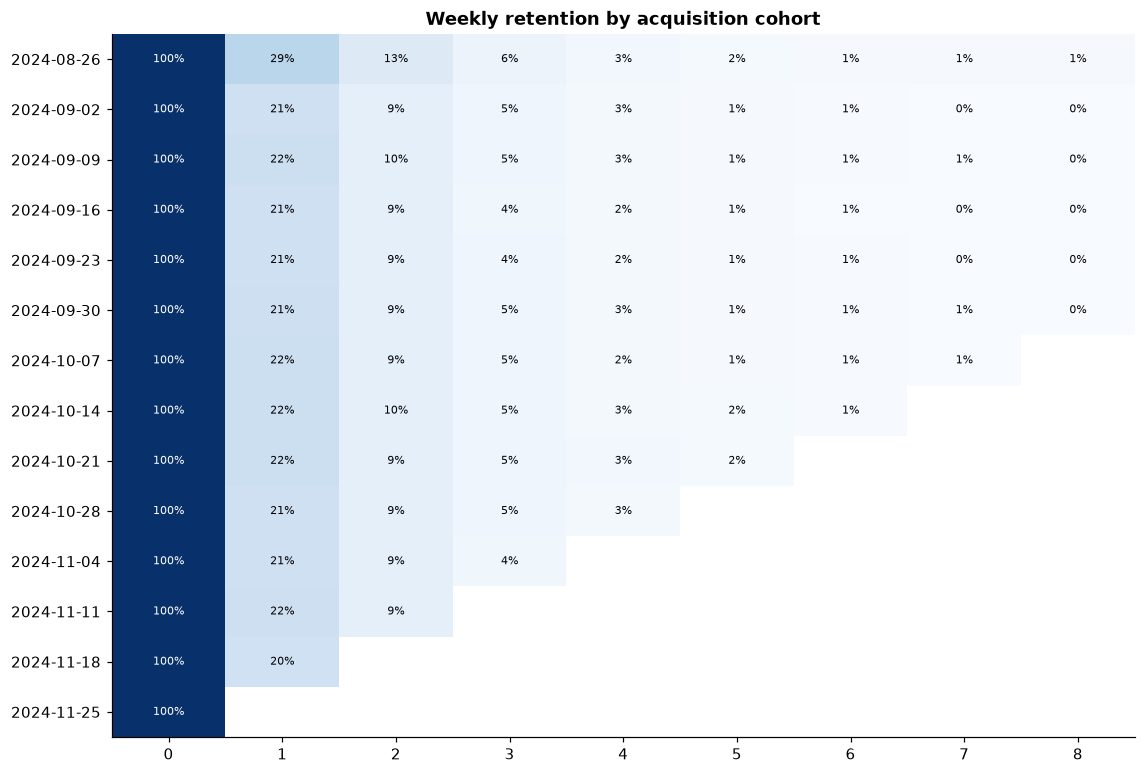

In [6]:
retention = metrics.cohort_matrix("retention_rate")
viz.save(viz.heatmap(retention.iloc[:, :9], "Weekly retention by acquisition cohort"), "03_cohort_retention")
retention.iloc[:, :9].round(3)

'reports\\figures\\03_retention_by_channel.png'

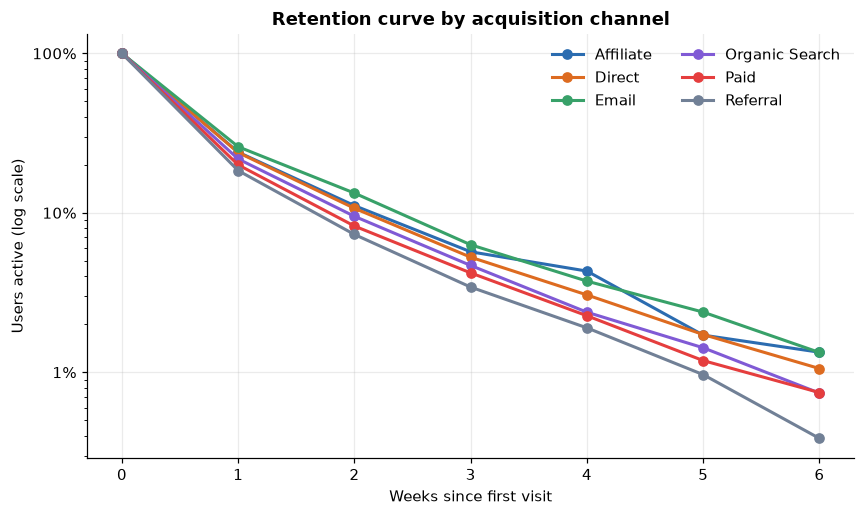

In [7]:
# Retention by channel, averaged over cohorts that have at least four weeks of
# history so young cohorts do not drag the curve down.
curve = query("""
SELECT acquisition_channel, week_index,
       sum(active_users) / sum(cohort_users) AS retention_rate
FROM fct_cohort_retention
WHERE weeks_observed >= 4 AND week_index BETWEEN 0 AND 6
GROUP BY 1, 2
ORDER BY 1, 2
""")

fig, ax = plt.subplots(figsize=(9, 5))
for i, (channel, part) in enumerate(curve.groupby("acquisition_channel")):
    ax.plot(part["week_index"], part["retention_rate"], marker="o", lw=2,
            color=viz.PALETTE[i % len(viz.PALETTE)], label=channel)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_xlabel("Weeks since first visit")
ax.set_ylabel("Users active (log scale)")
ax.set_title("Retention curve by acquisition channel")
ax.legend(frameon=False, ncols=2)
viz.save(fig, "03_retention_by_channel")

In [8]:
# Where users end up in the lifecycle. Most of them never see a product page,
# which is the top of the funnel problem seen from the user side.
query("""
SELECT lifecycle_segment,
       count(*)                                     AS users,
       round(count(*) / (SELECT count(*) FROM dim_users), 4) AS share,
       round(avg(total_sessions), 2)                AS sessions_per_user,
       round(sum(total_revenue), 2)                 AS revenue
FROM dim_users
GROUP BY 1
ORDER BY users DESC
""")

,lifecycle_segment,users,share,sessions_per_user,revenue
0,Browser,83508,0.5567,1.58,0.00
1,Bounced,48121,0.3208,1.11,0.00
2,Cart abandoner,11308,0.0754,2.17,0.00
3,One time customer,3782,0.0252,2.63,264605.03
4,Checkout abandoner,2947,0.0196,2.37,0.00
5,Repeat customer,334,0.0022,4.62,47876.10


## Repeat purchase

The window is one quarter, so this understates repeat behaviour for anyone acquired in November. It is still enough to compare channels against each other.

In [9]:
repeat = metrics.repeat_purchase_metrics()
repeat["repeat_rate"] = (repeat["repeat_customers"] / repeat["customers"]).round(4)
repeat

,acquisition_channel,customers,repeat_customers,days_to_first_purchase,days_to_second_purchase,orders_per_customer,aov,revenue,repeat_rate
0,Paid,1214,98,5.9,9.2,1.09,68.72,90612.20,0.0807
1,Direct,1214,99,5.7,10.5,1.09,68.39,89437.17,0.0815
2,Organic Search,977,71,5.9,8.9,1.09,71.45,76100.85,0.0727
3,Email,455,52,5.5,9.6,1.13,69.68,36086.67,0.1143
4,Referral,140,4,5.4,6.3,1.03,76.69,10993.16,0.0286
5,Affiliate,116,10,6.5,11.1,1.09,73.60,9251.08,0.0862


In [10]:
query("""
SELECT
  count(*)                                                 AS orders,
  count(*) FILTER (WHERE order_seq > 1)                    AS repeat_orders,
  round(count(*) FILTER (WHERE order_seq > 1) / count(*), 4) AS repeat_order_share,
  round(sum(order_value) FILTER (WHERE order_seq > 1) / sum(order_value), 4) AS repeat_revenue_share,
  round(avg(order_value) FILTER (WHERE order_seq = 1), 2)  AS aov_first_order,
  round(avg(order_value) FILTER (WHERE order_seq > 1), 2)  AS aov_repeat_order,
  round(median(days_since_previous_order), 1)              AS median_days_between_orders
FROM fct_orders
""")

,orders,repeat_orders,repeat_order_share,repeat_revenue_share,aov_first_order,aov_repeat_order,median_days_between_orders
0,4492,376,0.0837,0.0824,69.66,68.5,6.5


,days_to_first_purchase,customers,cumulative_share
0,0,1720,0.417881
1,1,147,0.453596
2,2,242,0.512391
3,3,249,0.572886
4,4,208,0.623421
5,5,178,0.666667
6,6,173,0.708698
7,7,133,0.741011
8,8,95,0.764091
9,9,96,0.787415


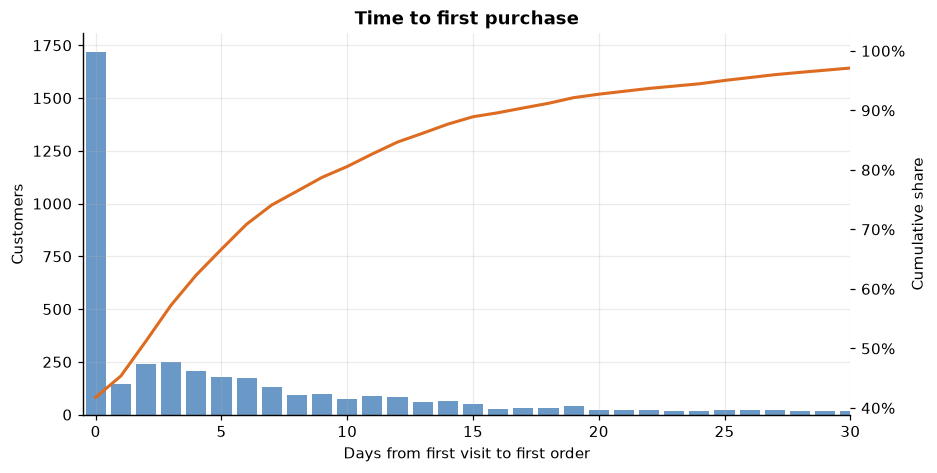

In [11]:
# How quickly a first purchase happens after the first visit. Most of it lands
# in the first week, which is the window any lifecycle campaign has to work in.
days = query("""
SELECT days_to_first_purchase, count(*) AS customers
FROM dim_users
WHERE is_customer
GROUP BY 1 ORDER BY 1
""")
days["cumulative_share"] = days["customers"].cumsum() / days["customers"].sum()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(days["days_to_first_purchase"], days["customers"], color=viz.PALETTE[0], alpha=0.7)
ax.set_xlim(-0.5, 30)
ax.set_xlabel("Days from first visit to first order")
ax.set_ylabel("Customers")
ax2 = ax.twinx()
ax2.plot(days["days_to_first_purchase"], days["cumulative_share"], color=viz.PALETTE[1], lw=2)
ax2.set_ylabel("Cumulative share")
ax2.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax2.grid(False)
ax.set_title("Time to first purchase")
viz.save(fig, "03_days_to_first_purchase")
days.head(10)

## Products and categories

In [12]:
categories = metrics.category_performance()
categories

,product_category,products,sessions_viewed,sessions_added,orders,units_sold,revenue,view_to_cart_rate,view_to_order_rate,avg_price,revenue_per_view_session
0,Apparel,30,103971.0,10140.0,2208.0,2665.0,102811.53,0.0975,0.0212,48.99,0.99
1,Accessories,25,79805.0,8311.0,1765.0,2131.0,54456.78,0.1041,0.0221,22.02,0.68
2,Bags,25,28328.0,2384.0,508.0,612.0,45261.64,0.0842,0.0179,77.43,1.60
3,Lifestyle,25,34668.0,3072.0,628.0,750.0,36709.32,0.0886,0.0181,53.23,1.06
4,Electronics,25,17553.0,1273.0,261.0,296.0,29662.70,0.0725,0.0149,113.87,1.69
5,Drinkware,25,29853.0,3228.0,657.0,791.0,16974.67,0.1081,0.0220,18.87,0.57
6,Office,25,22711.0,2446.0,511.0,598.0,14440.14,0.1077,0.0225,19.89,0.64
7,Stationery,20,23313.0,2478.0,537.0,658.0,8727.81,0.1063,0.0230,9.51,0.37
8,Headgear,20,8492.0,804.0,160.0,189.0,3436.54,0.0947,0.0188,23.47,0.40


In [13]:
products = metrics.product_performance(min_views=300)
top = products.head(15)[["product_name", "product_category", "avg_price", "sessions_viewed",
                         "view_to_cart_rate", "view_to_order_rate", "units_sold", "revenue"]]
top

,product_name,product_category,avg_price,sessions_viewed,view_to_cart_rate,view_to_order_rate,units_sold,revenue
0,Google Olive Sunglasses,Accessories,28.09,34114,0.1058,0.0226,943.0,26488.87
1,Google Navy Cap Sleeve Tee,Apparel,19.77,32690,0.1034,0.0230,936.0,18504.72
2,Google Black Lanyard,Accessories,27.95,18910,0.1025,0.0226,516.0,14422.20
3,Google Olive Long Sleeve Tee,Apparel,61.92,7772,0.0941,0.0214,195.0,12074.40
4,Google Black Cap Sleeve Tee,Apparel,29.41,11692,0.0990,0.0220,297.0,8734.77
5,Google Olive Picnic Set,Lifestyle,86.23,4973,0.0877,0.0171,100.0,8623.00
6,Google Navy Backpack,Bags,90.41,4894,0.0772,0.0147,92.0,8317.72
7,Google White Long Sleeve Tee,Apparel,68.69,4970,0.0946,0.0201,115.0,7899.35
8,Google Black Pencil Pack,Stationery,14.44,17214,0.1061,0.0236,508.0,7335.52
9,Google Charcoal Bluetooth Speaker,Electronics,202.33,2048,0.0688,0.0156,36.0,7283.88


46 of 220 products cover 80% of revenue


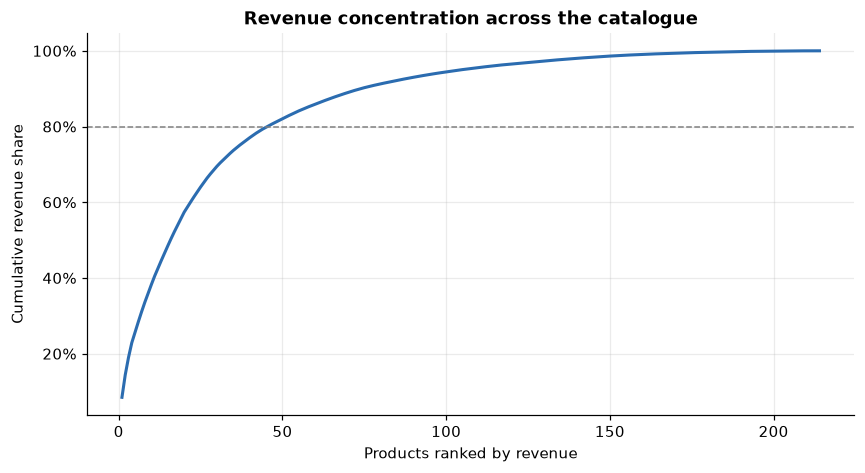

In [14]:
# How concentrated revenue is. Useful for deciding whether merchandising effort
# should go wide or into a short head of products.
pareto = query("SELECT revenue_rank, cumulative_revenue_share FROM fct_product_performance ORDER BY revenue_rank")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(pareto["revenue_rank"], pareto["cumulative_revenue_share"], color=viz.PALETTE[0], lw=2)
ax.axhline(0.8, color="grey", ls="--", lw=1)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_xlabel("Products ranked by revenue")
ax.set_ylabel("Cumulative revenue share")
ax.set_title("Revenue concentration across the catalogue")
viz.save(fig, "03_revenue_pareto")

n80 = int((pareto["cumulative_revenue_share"] < 0.8).sum()) + 1
print(f"{n80} of {len(pareto)} products cover 80% of revenue")

In [15]:
# Products with plenty of traffic and a weak cart rate. These are merchandising
# or pricing problems rather than demand problems.
weak = products.query("sessions_viewed > 800").nsmallest(10, "view_to_cart_rate")
weak[["product_name", "product_category", "avg_price", "sessions_viewed", "view_to_cart_rate", "revenue"]]

,product_name,product_category,avg_price,sessions_viewed,view_to_cart_rate,revenue
28,Google White Bluetooth Speaker,Electronics,169.81,1036,0.0647,3226.39
25,Google White USB-C Hub,Electronics,130.77,1625,0.0658,3792.33
32,Google Charcoal Earbuds Case,Electronics,86.34,2081,0.0668,2590.20
9,Google Charcoal Bluetooth Speaker,Electronics,202.33,2048,0.0688,7283.88
6,Google Navy Backpack,Bags,90.41,4894,0.0772,8317.72
40,Google Olive Duffel Bag,Bags,115.15,843,0.0783,1957.55
26,Google Charcoal Blanket,Lifestyle,83.28,1653,0.0786,3664.32
46,Google Olive Earbuds Case,Electronics,29.00,2738,0.0796,1450.00
47,Google Charcoal Candle,Lifestyle,44.81,1764,0.0799,1389.11
54,Google Navy Long Sleeve Tee,Apparel,73.27,1001,0.0819,1245.59


## Reading of this notebook

Paid social sends about one in six new users and returns a small fraction of that in revenue, while email sends very few users and returns several times more per user than any other channel. Retention drops hard after week 1 for every channel, so the quarter is carried by first purchases rather than by a returning base. Revenue is concentrated in a short head of the catalogue, mostly in Apparel and Accessories.